In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import pandas as pd

from src.kinetics_model import solve_kinetics, calculate_conversion

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Librerie importate")

✅ Librerie importate


In [2]:
# Parametri ottimizzati dal Giorno 3
k1_opt = 0.0666
k2_opt = 1.0
k3_opt = 1.0

# Condizioni iniziali
TG0 = 1.0
initial_C = [TG0, 0, 0, 0, 0]
t = np.linspace(0, 60, 100)

# Variazione di k1: ±20%, ±40%
variations = [-0.4, -0.2, 0, 0.2, 0.4]
colors = ['red', 'orange', 'blue', 'green', 'purple']
labels = ['-40%', '-20%', 'k1 ottimale', '+20%', '+40%']

print("Analisi di sensitività su k1 (parametro cinetico principale)")

Analisi di sensitività su k1 (parametro cinetico principale)


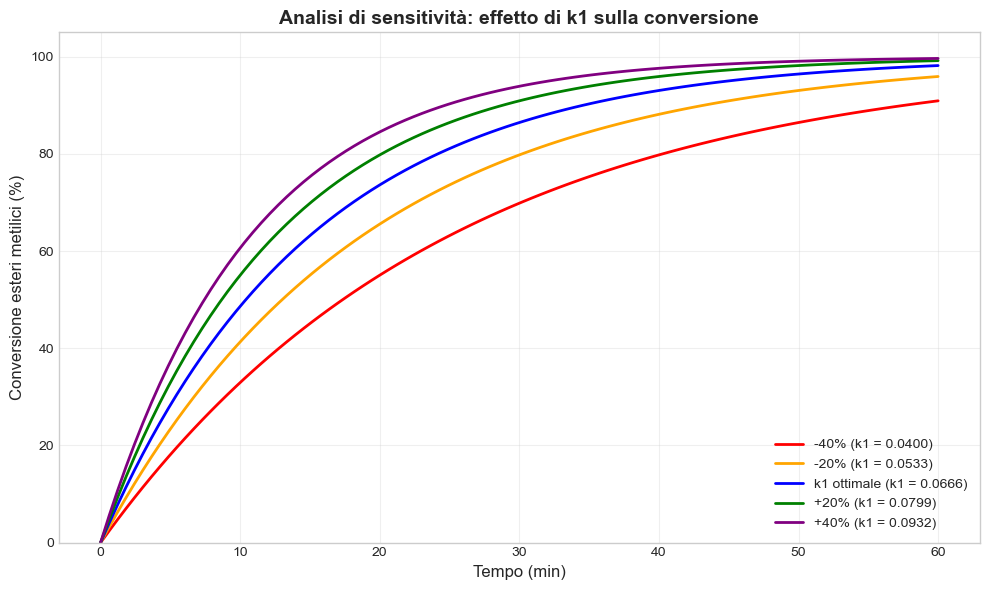

✅ Grafico salvato in output/sensitivity_k1.png


In [3]:
# Crea grafico
fig, ax = plt.subplots(figsize=(10, 6))

for var, color, label in zip(variations, colors, labels):
    k1_test = k1_opt * (1 + var)
    k_test = [k1_test, k2_opt, k3_opt]
    
    solution = solve_kinetics(initial_C, t, k_test)
    conversion = calculate_conversion(solution)
    
    ax.plot(t, conversion, color=color, linewidth=2, label=f'{label} (k1 = {k1_test:.4f})')

ax.set_xlabel('Tempo (min)', fontsize=12)
ax.set_ylabel('Conversione esteri metilici (%)', fontsize=12)
ax.set_title('Analisi di sensitività: effetto di k1 sulla conversione', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('../output/sensitivity_k1.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Grafico salvato in output/sensitivity_k1.png")